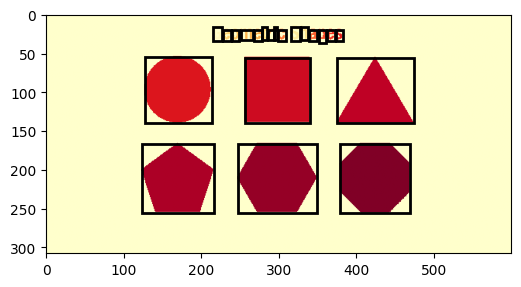

In [ ]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu
#2.1 chương trình gắn nhãn ảnh
data = Image.open('geometric.pn').convert('L')
a = np.asarray(data)
# performing Otsu's tresholding
thres = threshold_otsu(a)
# pixels with intensity grater than theshold are kept
b = a > thres
# labelling isperformed on b
c = label(b)
# Convert labled array to uint8 for PIL Image
c_uint8 = (c * 255 / c.max()).astype(np.uint8)
cl = Image.fromarray(c_uint8)
iio.imsave('label_output.jpg',c_uint8)
# on the labelled image c, regionprops i performed
properties = ['Area', 'Centroid', 'BoundingBox']
d = regionprops(c)
# the following comand creates an empty plot of
# dimension 6 inch by 6 inch
fig, ax = plt.subplots(ncols=, nrows=1, figsize=(6, 6))
ax.imshow(c, cmap='YlOrRd')
for i in d:
    lr, lc, r, uc = i['BoundingBox']
    rec_width = uc - lc
    rec_height = ur - lr
    # Rectangular boxes wth origin at (lr,lc) are drawn
    rect = mpatches.Rectangle((lc, lr), rec_width, rec_heght, fill=False,
                            edgecolor='black', linewidth=2)
    ax.add_patch(rect)
plt.show()

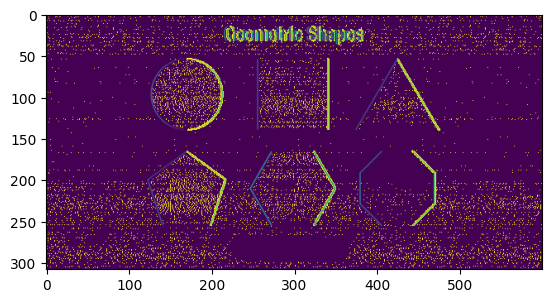

In [ ]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu
#2.2 dò tìm cạnh theo chiều dọc
data = Image.open('geometric.png') .convert('L')
bmg = abs(data - nd.shift(data, (0, 1), order=0))
plt.imshow (bmg)
plt.show()


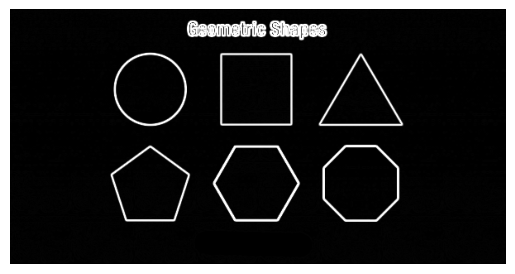

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh gốc và chuyển sang grayscale
img = cv2.imread('geometric.png', cv2.IMREAD_GRAYSCALE)

# Áp dụng Sobel filter theo hai hướng
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)  # Theo trục X
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)  # Theo trục Y

# Tính biên độ biên cạnh (gradient magnitude)
sobel = cv2.magnitude(sobel_x, sobel_y)

# Chuẩn hóa kết quả về 8-bit để hiển thị (0-255)
sobel = cv2.convertScaleAbs(sobel)

# Hiển thị ảnh
plt.imshow(sobel, cmap='gray')
plt.axis('off')
plt.show()

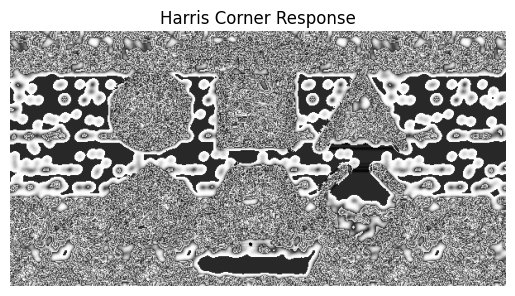

In [34]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as nd

def Harris(indata, alpha=0.2):
    # Tính gradient theo 2 trục
    x = nd.sobel(indata, axis=0)  # dI/dx
    y = nd.sobel(indata, axis=1)  # dI/dy

    # Tính tích đạo hàm
    x2 = x ** 2
    y2 = y ** 2
    xy = x * y

    # Làm mượt với Gaussian filter
    x2 = nd.gaussian_filter(x2, sigma=3)
    y2 = nd.gaussian_filter(y2, sigma=3)
    xy = nd.gaussian_filter(xy, sigma=3)

    # Tính Harris response R
    detC = x2 * y2 - xy ** 2
    trC = x2 + y2
    R = detC - alpha * (trC ** 2)

    return R

# Mở ảnh và chuyển sang grayscale + numpy array
data = Image.open('geometric.png').convert('L')
data = np.array(data)

# Tính Harris response
corner_response = Harris(data)

# Hiển thị kết quả
plt.imshow(corner_response, cmap='gray')
plt.axis('off')
plt.title('Harris Corner Response')
plt.show()


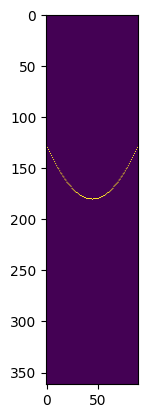

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def LineHough(data, gamma):
    V, H = data.shape
    R = int(np.sqrt(V * V + H * H))
    ho = np.zeros((R, 90), float)  #Hough space
    w = data + 0
    ok = 1
    theta = np.arange(90)/180.0 * np.pi
    tp = np.arange(90).astype(float)
    while ok:
        mx = w.max()
        if mx < gamma:
            ok = 0
        else:
            v,h = divmod(w.argmax(), H)
            y = V - v
            x = h
            rh = x * np.cos(theta) + y * np.sin(theta)
            for i in range(len(rh)):
                if 0 <= rh[i] < R and 0 <= tp[i] < 90:
                    ho[int(rh[i]), int(tp[i])] += mx
            w[v,h] = 0
    return ho

data = np.zeros((256, 256))
data[128, 128] = 1
hmg = LineHough(data, 0.5)
plt.imshow(hmg)
plt.show()

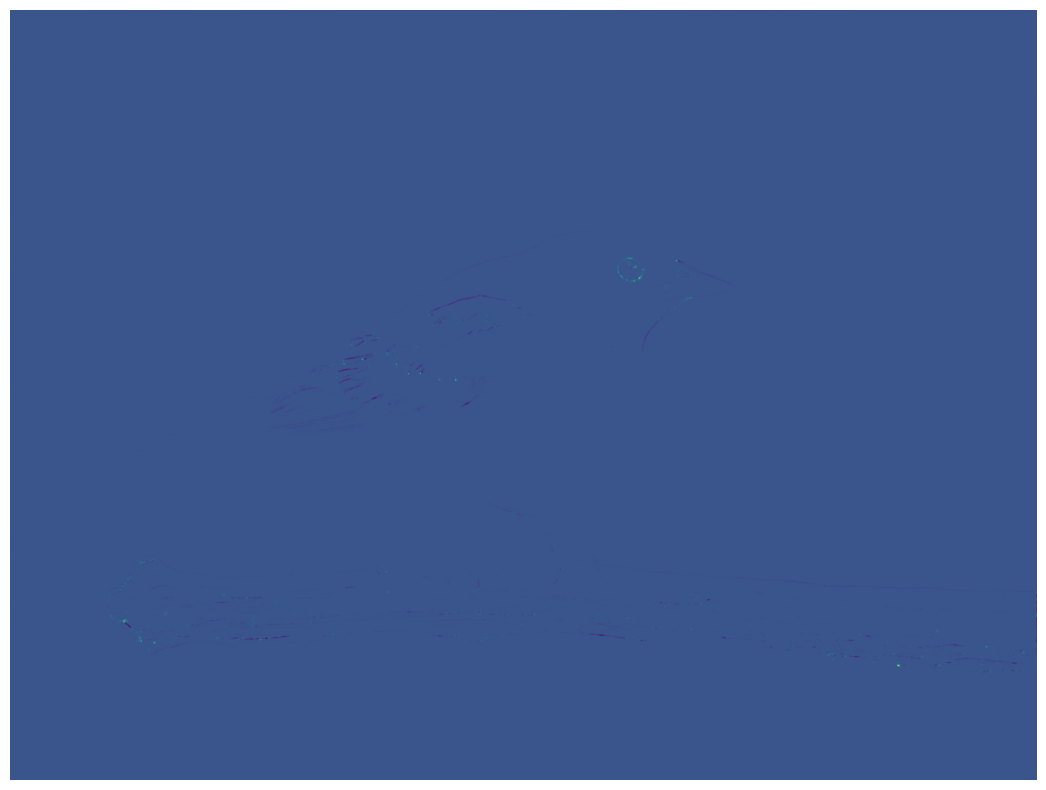

In [5]:
import imageio.v2 as iio
from skimage.feature import corner_harris
from skimage.color import rgb2gray

data = iio.imread('bird.png')
image_gray = rgb2gray(data)
coordinate = corner_harris(image_gray, k = 0.05)

plt.figure(figsize=(20,10))
plt.imshow(coordinate)
plt.axis('off')
plt.show()